In [1]:
import chess.pgn
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [9]:
data_path = "../data/raw/"

pgn = open(data_path+"mates.pgn")
cnt = 0
inv = 0
piece_select_fen = []

piece_type_data = {
    chess.PAWN: [],
    chess.QUEEN: [],
    chess.ROOK: [],
    chess.BISHOP: [],
    chess.KNIGHT: [],
    chess.KING: []
}

while True:
    game = chess.pgn.read_game(pgn)
    if game is None:
        break
    cnt+=1
    if cnt % 5000 == 0:
        print(cnt)

    board = game.board()
    for move in game.mainline_moves():
        if board.turn:
            fen = board.fen() 
            move_from = move.from_square
            move_to = move.to_square
            try:
                piece_list = board.piece_at(move_from).piece_type
            except Exception:
                inv += 1
                break
        else:
            tmp_board = board.mirror()
            fen = tmp_board.fen()
            move_from = chess.square_mirror(move.from_square)
            move_to = chess.square_mirror(move.to_square)
            try:
                piece_list = tmp_board.piece_at(move_from).piece_type
            except Exception:
                inv += 1
                break
        
        piece_select_data = fen + "," + chess.square_name(move_from)
        move_data = piece_select_data + chess.square_name(move_to)
        piece_select_fen.append(piece_select_data)
        piece_type_data[piece_list].append(move_data)

        board.push(move)

print("Inv: ", inv)


5000
10000
15000
20000
25000
30000
35000
40000
45000
50000
Inv:  145


In [12]:
names = []
nums = []

for piece_type, move_list in piece_type_data.items():
    piece_name = chess.piece_name(piece_type)
    names.append(piece_name)
    nums.append(len(move_list))
    with open(data_path + f"mlp/{piece_name}.txt", "w") as f:
        f.writelines(line + "\n" for line in move_list)

with open(data_path + f"mlp/piece_select.txt", "w") as f:
    f.writelines(line + "\n" for line in piece_select_fen)


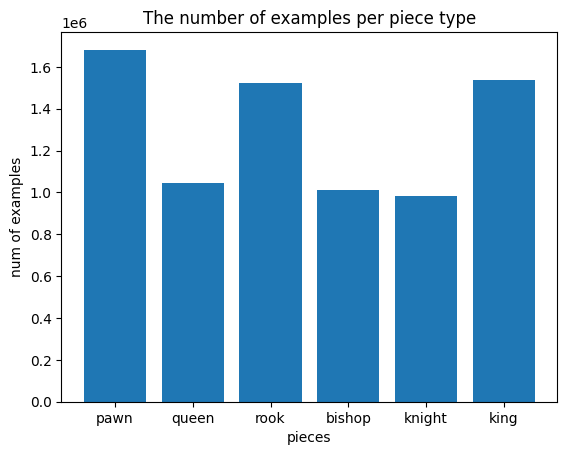

In [13]:
plt.bar(names, nums)
plt.xlabel("pieces")
plt.ylabel("num of examples")
plt.title("The number of examples per piece type")
plt.show()

In [17]:
import chess
import torch

def board_to_matrix_move(board: chess.Board, move: chess.Move):
    matrix_board = torch.zeros((6, 8, 8))
    matrix_move = torch.zeros(64)
    matrix_move_to = torch.zeros(64)

    for i in range(8):
        for j in range(8):
            piece = board.piece_at(chess.square(i, j))
            if piece is not None:
                piece_type = piece.piece_type
                piece_color = piece.color
                index = piece_type - 1
                if piece_color == chess.WHITE:
                    matrix_board[index, 7-j, i] = 1
                else:
                    matrix_board[index, 7-j, i] = -1

    matrix_move[move.from_square] = 1
    matrix_move_to[move.to_square] = 1
    return torch.cat((matrix_board, matrix_move.reshape(8, 8).unsqueeze(0)), dim=0), matrix_move_to


def board_to_matrix_selection(board: chess.Board, square: chess.Square):
    matrix_board = torch.zeros((6, 8, 8))
    matrix_move = torch.zeros(64)

    for i in range(8):
        for j in range(8):
            piece = board.piece_at(chess.square(i, j))
            if piece is not None:
                piece_type = piece.piece_type
                piece_color = piece.color
                index = piece_type - 1
                if piece_color == chess.WHITE:
                    matrix_board[index, 7-j, i] = 1
                else:
                    matrix_board[index, 7-j, i] = -1

    matrix_move[square] = 1
    return matrix_board, matrix_move


In [15]:
prep_path = "../data/prep/mlp/"
data_path = "../data/raw/"

piece_types = [chess.PAWN, chess.QUEEN, chess.KING, chess.ROOK, chess.BISHOP, chess.KNIGHT]

for piece_type in piece_types:
    piece_name = chess.piece_name(piece_type)
    with open(data_path + f"mlp/{piece_name}.txt", "r") as f:
        move_list = f.readlines()

    x_data, y_data = [], []
    for line in move_list:
        fen, move = line.split(",")
        idx = fen.find("[")
        if idx != -1:
            fen = fen[:idx]
        board, move = chess.Board(fen), chess.Move.from_uci(move[:-1])
        tensor, label = board_to_matrix_move(board, move)
        x_data.append(tensor)
        y_data.append(label)
    x = torch.stack(x_data)
    y = torch.stack(y_data)
    torch.save(x, f"{prep_path}X_{piece_name}.pt")
    torch.save(y, f"{prep_path}y_{piece_name}.pt")


In [18]:
with open(data_path + f"mlp/piece_select.txt", "r") as f:
    move_list = f.readlines()

x_data, y_data = [], []
for line in move_list:
    fen, move = line.split(",")
    idx = fen.find("[")
    if idx != -1:
        fen = fen[:idx]
    board, move = chess.Board(fen), chess.parse_square(move[:-1])
    tensor, label = board_to_matrix_selection(board, move)
    x_data.append(tensor)
    y_data.append(label)
x = torch.stack(x_data)
y = torch.stack(y_data)
torch.save(x, f"{prep_path}X_selection.pt")
torch.save(y, f"{prep_path}y_selection.pt")

InvalidMoveError: expected uci string to be of length 4 or 5: 'e2'